In [1]:
from tmtools.io import get_residue_data, get_structure
from tmtools.helpers import transform_structure
from tmtools import tm_align
import glob
import matplotlib.pyplot as plt
# Load structures
from Bio.PDB import PDBParser
from Bio.PDB.PDBIO import PDBIO
import math
from tqdm import tqdm
import numpy as np
import json
import pandas as pd
import seaborn as sns
import biotite.structure.io
import biotite.structure as struct
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib

In [22]:
from alphafold.relax import relax
from alphafold.relax import utils
from alphafold.common import protein, residue_constants

MODRES = {'MSE':'MET','MLY':'LYS','FME':'MET','HYP':'PRO',
          'TPO':'THR','CSO':'CYS','SEP':'SER','M3L':'LYS',
          'HSK':'HIS','SAC':'SER','PCA':'GLU','DAL':'ALA',
          'CME':'CYS','CSD':'CYS','OCS':'CYS','DPR':'PRO',
          'B3K':'LYS','ALY':'LYS','YCM':'CYS','MLZ':'LYS',
          '4BF':'TYR','KCX':'LYS','B3E':'GLU','B3D':'ASP',
          'HZP':'PRO','CSX':'CYS','BAL':'ALA','HIC':'HIS',
          'DBZ':'ALA','DCY':'CYS','DVA':'VAL','NLE':'LEU',
          'SMC':'CYS','AGM':'ARG','B3A':'ALA','DAS':'ASP',
          'DLY':'LYS','DSN':'SER','DTH':'THR','GL3':'GLY',
          'HY3':'PRO','LLP':'LYS','MGN':'GLN','MHS':'HIS',
          'TRQ':'TRP','B3Y':'TYR','PHI':'PHE','PTR':'TYR',
          'TYS':'TYR','IAS':'ASP','GPL':'LYS','KYN':'TRP',
          'CSD':'CYS','SEC':'CYS'}

def pdb_to_string(pdb_file, chains=None, models=[1]):
  '''read pdb file and return as string'''

  if chains is not None:
    if "," in chains: chains = chains.split(",")
    if not isinstance(chains,list): chains = [chains]
  if models is not None:
    if not isinstance(models,list): models = [models]

  modres = {**MODRES}
  lines = []
  seen = []
  model = 1
  for line in open(pdb_file,"rb"):
    line = line.decode("utf-8","ignore").rstrip()
    if line[:5] == "MODEL":
      model = int(line[5:])
    if models is None or model in models:
      if line[:6] == "MODRES":
        k = line[12:15]
        v = line[24:27]
        if k not in modres and v in residue_constants.restype_3to1:
          modres[k] = v
      if line[:6] == "HETATM":
        k = line[17:20]
        if k in modres:
          line = "ATOM  "+line[6:17]+modres[k]+line[20:]
      if line[:4] == "ATOM":
        chain = line[21:22]
        if chains is None or chain in chains:
          atom = line[12:12+4].strip()
          resi = line[17:17+3]
          resn = line[22:22+5].strip()
          if resn[-1].isalpha(): # alternative atom
            resn = resn[:-1]
            line = line[:26]+" "+line[27:]
          key = f"{model}_{chain}_{resn}_{resi}_{atom}"
          if key not in seen: # skip alternative placements
            lines.append(line)
            seen.append(key)
      if line[:5] == "MODEL" or line[:3] == "TER" or line[:6] == "ENDMDL":
        lines.append(line)
  return "\n".join(lines)

def relax_me(pdb_in, pdb_out, max_iterations, tolerance, stiffness, use_gpu):
  pdb_str = pdb_to_string(pdb_in)
  protein_obj = protein.from_pdb_string(pdb_str)
  amber_relaxer = relax.AmberRelaxation(
    max_iterations=max_iterations,
    tolerance=tolerance,
    stiffness=stiffness,
    exclude_residues=[],
    max_outer_iterations=3,
    use_gpu=use_gpu
  )
  relaxed_pdb_lines, debug_data, violations = amber_relaxer.process(prot=protein_obj)
  with open(pdb_out, 'w') as f:
      f.write(relaxed_pdb_lines)
  with open(pdb_out.replace('.pdb', '_stats.json'), 'w') as f:
      f.write(str(debug_data))

In [2]:
guides = [biotite.structure.io.load_structure("6IRS_B.pdb"), biotite.structure.io.load_structure("7DSQ_B.pdb")]

guides = [guides[0][guides[0].atom_name == "CA"], guides[1][guides[1].atom_name == "CA"][7:-1]]

guides[1], _ = struct.superimpose(guides[0], guides[1])


rms = struct.rmsd(guides[0], guides[1])

print(np.around(rms, decimals=3))


prots = {
    "rmsd": [[], []],
    "tm": [[], []],
    "msa_batch": [],
    "mean_plddt": [],
    "subsample_sz": [],
    "mask_fraction": [],
    "rank": [],
    "filename": []}

#archive/25052026/*/*/predictions/*/*.pdb
for i in tqdm(glob.glob("localcolabfold/runs/*/*/predictions/*/*.pdb")):
#for i in glob.glob("boltz_7DSQ_*/*/predictions/*/*.pdb"):

    mobile_struct = biotite.structure.io.load_structure(i)
    mobile_struct = mobile_struct[mobile_struct.atom_name == "CA"][7:]
    mobile_struct, _ = struct.superimpose(guides[0], mobile_struct)
    #print(i)
    # Run TMalign
    #print(i + ":")
    try:
        prots["rank"].append(int(i.split("rank_")[1].split("_alpha")[0]))
    except:
        print(i)
        continue
    prots["msa_batch"].append(0)
    prots["subsample_sz"].append(int(i.split('predictions')[1].split("/")[1]))
    
    prots["mean_plddt"].append(np.mean(json.load(open(i.replace("unrelaxed", "scores").replace(".pdb", ".json")))["plddt"]))
    prots["filename"].append(i)
    prots["mask_fraction"].append(int(i.split("/")[-1].split("_")[3]))
    for j in range(len(guides)):
        prots["tm"][j].append(struct.tm_score(guides[j], mobile_struct, np.arange(len(guides[j])), np.arange(len(guides[j]))))
        prots["rmsd"][j].append(np.around(struct.rmsd(guides[j], mobile_struct), decimals=3))
        #print(res.rmsd, res.tm_norm_chain1, res.tm_norm_chain2)
        
        
prt = {
 "7DSQ_rmsd": prots["rmsd"][1], 
 "6IRS_rmsd": prots["rmsd"][0],
 "6IRS_tm": prots["tm"][0],
 "7DSQ_tm": prots["tm"][1],
 "rank": prots["rank"],
 "msa_batch": prots["msa_batch"],
 "mean_plddt": prots["mean_plddt"],
 "MSA Samples": [int(x) for x in prots["subsample_sz"]],
 "MSA Mask %": prots["mask_fraction"],
 "pdb_filename": prots["filename"]
}
df = pd.DataFrame(prt)

3.534


  0%|                                                                                                                                                  | 0/1875 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1875/1875 [00:14<00:00, 131.43it/s]


In [26]:
guides = [biotite.structure.io.load_structure("6IRS_B.pdb"), biotite.structure.io.load_structure("7DSQ_B.pdb")]

guides = [guides[0][guides[0].atom_name == "CA"], guides[1][guides[1].atom_name == "CA"][7:-1]]

guides[1], _ = struct.superimpose(guides[0], guides[1])


rms = struct.rmsd(guides[0], guides[1])

print(np.around(rms, decimals=3))


prots = {
    "rmsd": [[], []],
    "tm": [[], []],
    "msa_batch": [],
    "mean_plddt": [],
    "subsample_sz": [],
    "mask_fraction": [],
    "rank": [],
    "filename": []}

#archive/25052026/*/*/predictions/*/*.pdb
for i in pareto_2.pdb_filename:
    fname = i.replace('unrelaxed', 'relaxed')
#for i in glob.glob("boltz_7DSQ_*/*/predictions/*/*.pdb"):

    mobile_struct = biotite.structure.io.load_structure(fname)
    mobile_struct = mobile_struct[mobile_struct.atom_name == "CA"][7:]
    mobile_struct, _ = struct.superimpose(guides[0], mobile_struct)
    #print(i)
    # Run TMalign
    #print(i + ":")
    try:
        prots["rank"].append(int(i.split("rank_")[1].split("_alpha")[0]))
    except:
        print(i)
        continue
    prots["msa_batch"].append(0)
    prots["subsample_sz"].append(int(i.split('predictions')[1].split("/")[1]))
    
    prots["mean_plddt"].append(np.mean(json.load(open(i.replace("unrelaxed", "scores").replace(".pdb", ".json")))["plddt"]))
    prots["filename"].append(i)
    prots["mask_fraction"].append(int(i.split("/")[-1].split("_")[3]))
    for j in range(len(guides)):
        prots["tm"][j].append(struct.tm_score(guides[j], mobile_struct, np.arange(len(guides[j])), np.arange(len(guides[j]))))
        prots["rmsd"][j].append(np.around(struct.rmsd(guides[j], mobile_struct), decimals=3))
        #print(res.rmsd, res.tm_norm_chain1, res.tm_norm_chain2)
        
        
prt = {
 "7DSQ_rmsd": prots["rmsd"][1], 
 "6IRS_rmsd": prots["rmsd"][0],
 "6IRS_tm": prots["tm"][0],
 "7DSQ_tm": prots["tm"][1],
 "rank": prots["rank"],
 "msa_batch": prots["msa_batch"],
 "mean_plddt": prots["mean_plddt"],
 "MSA Samples": [int(x) for x in prots["subsample_sz"]],
 "MSA Mask %": prots["mask_fraction"],
 "pdb_filename": prots["filename"]
}
relaxed_pareto2_df = pd.DataFrame(prt)

3.534


In [3]:
def get_pareto_front(df, x_col, y_col):
    """
    Returns the subset of the dataframe that forms the Pareto Front
    (maximizing both x and y).
    """
    # 1. Sort by X descending. If X is the same, sort by Y descending.
    df_sorted = df.sort_values(by=[x_col, y_col], ascending=False).reset_index(drop=False)
    
    pareto_front = []
    max_y = -float('inf')
    
    # 2. Iterate through sorted points
    # Because we are sorted by X (best first), a point is only 'best' 
    # if its Y is better than any Y we've seen so far.
    for idx, row in df_sorted.iterrows():
        if row[y_col] > max_y:
            pareto_front.append(row['index']) # Keep original dataframe index
            max_y = row[y_col]
            
    return df.loc[pareto_front]


In [4]:
pareto_df =get_pareto_front(df, '7DSQ_tm', '6IRS_tm')

In [5]:
pareto_2 = pd.concat([pareto_df, get_pareto_front(pd.concat([df, pareto_df]).drop_duplicates(keep=False), '7DSQ_tm', '6IRS_tm')])

In [23]:
for i in tqdm(pareto_2.pdb_filename):
    relax_me(
        pdb_in=i,
        pdb_out=i.replace('unrelaxed', 'relaxed'),
        max_iterations=2000,
        tolerance=2.39,
        stiffness=10.0,
        use_gpu=True
    )

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [09:30<00:00,  4.63s/it]


In [20]:
pareto_5.pdb_filename.iloc[0]

'localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predictions/128/7DSQ_2_0_5_2_unrelaxed_rank_012_alphafold2_model_5_seed_001.pdb'

In [7]:
pareto_5 =get_pareto_front(df, '7DSQ_tm', '6IRS_tm')
for i in range(5):
    pareto_5 = pd.concat([pareto_5, get_pareto_front(pd.concat([df, pareto_5]).drop_duplicates(keep=False), '7DSQ_tm', '6IRS_tm')])
#pareto_5 = pd.concat([pareto_df, get_pareto_front(pd.concat([df, pareto_df]).drop_duplicates(keep=False), '7DSQ_tm', '6IRS_tm')])

In [17]:
len(guides[0])

457

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:00<00:00, 139.75it/s]


[[-52.125095    10.162908  ]
 [ 50.891888     5.3216047 ]
 [ 47.42164      2.743575  ]
 [ 44.28237      6.6675324 ]
 [ 42.747005    11.187063  ]
 [ 44.664646     4.1308174 ]
 [ 39.59447      6.629362  ]
 [ 40.586273    15.654396  ]
 [ 37.25098      4.543383  ]
 [ 33.677395   -19.083078  ]
 [ 30.576939    -2.0447087 ]
 [ 32.786983    18.699316  ]
 [ 29.639196     2.5610976 ]
 [ 27.22917     12.237201  ]
 [ 24.349405    -6.775655  ]
 [ 23.410425    -7.80393   ]
 [ 20.377796    -8.683773  ]
 [ 19.378414    -0.24710716]
 [ 16.737085   -23.517355  ]
 [ 11.855714     5.2287    ]
 [  9.808086   -11.3234625 ]
 [  8.389092    -4.8554945 ]
 [  5.5909843   -8.797871  ]
 [  3.7324076   17.397131  ]
 [  4.935043   -13.113937  ]
 [  2.1337373   -8.896304  ]
 [  0.7317865   -6.819052  ]
 [  0.28535503 -21.172327  ]
 [  1.4133208  -24.59124   ]
 [ -3.7211576  -31.836214  ]
 [ -3.6103494  -31.82782   ]
 [ -4.331396    11.059283  ]
 [ -1.3036164    6.277533  ]
 [ -5.444283    -0.47287402]
 [ -7.8247495 

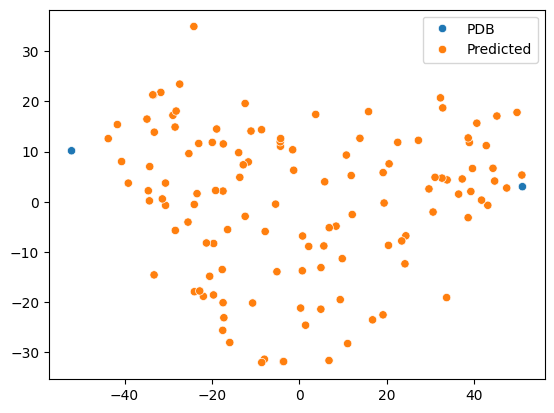

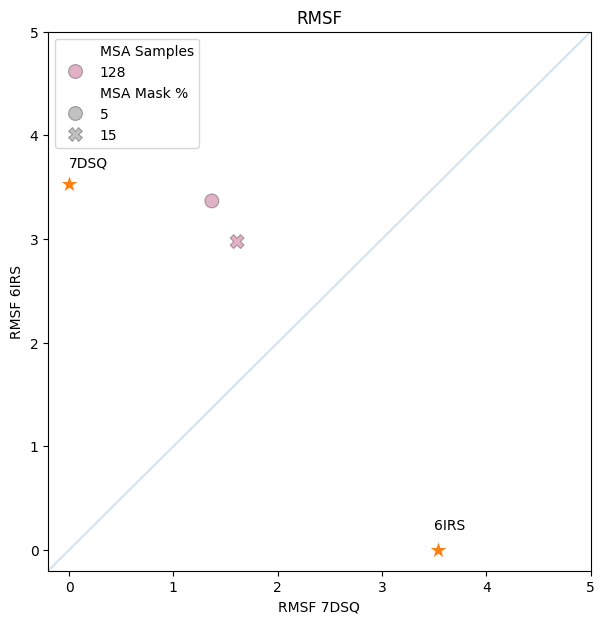

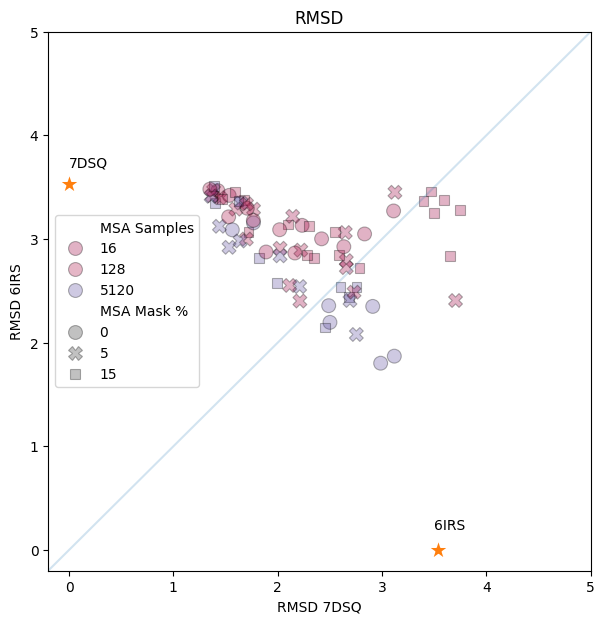

In [25]:
all_models = {}
full_stack = [guides[0].coord.flatten()]

scaler = StandardScaler()
for i in tqdm(pareto_2.pdb_filename):
    fname = i#i.replace('unrelaxed', 'relaxed')
#for i in tqdm(glob.glob("localcolabfold/runs/*/*_0_*/predictions/*/*.pdb")):
#for i in glob.glob("boltz_7DSQ_*/*/predictions/*/*.pdb"):
    
    mobile_struct = biotite.structure.io.load_structure(fname)
    mobile_struct = mobile_struct[mobile_struct.atom_name == "CA"][7:]
    if(len(mobile_struct.coord.flatten()) != len(guides[0].coord.flatten())): 
        continue
    mobile_struct, _ = struct.superimpose(guides[0], mobile_struct)
    if i.split('predictions')[1].split("/")[1] + '_' + i.split("/")[-1].split("_")[3] not in all_models.keys():
        all_models[i.split('predictions')[1].split("/")[1] + '_' + i.split("/")[-1].split("_")[3]] = []
    
    all_models[i.split('predictions')[1].split("/")[1] + '_' + i.split("/")[-1].split("_")[3]].append(mobile_struct)
    full_stack.append(mobile_struct.coord.flatten())
    #print(i)
    # Run TMalign
    #print(i + ":")

full_stack.append(struct.superimpose(guides[0], guides[1])[0].coord.flatten())

pca = PCA(n_components=2)
scaler.fit(np.array(full_stack))
components =pca.fit_transform(scaler.transform(np.array(full_stack)))


rmsfs = {}



rmsf = {
    "rmsf": [[], []],
    "msa_batch": [],
    "mean_plddt": [],
    "subsample_sz": [],
    "mask_fraction": []}


for k in all_models.keys():
    try:
        all_models[k] = struct.stack(all_models[k])
    except: 
        #print(k)
        continue
    rm = []
    for j in range(len(guides)):    
        rmsf["rmsf"][j].append(np.sqrt(np.mean(np.square(struct.rmsf(guides[j], all_models[k])))))
        rm.append(struct.rmsf(guides[j], all_models[k]))
    rmsf["msa_batch"].append(0)
    rmsf["mean_plddt"].append(0)
    rmsf["subsample_sz"].append(k.split("_")[0])
    rmsf["mask_fraction"].append(int(k.split("_")[1]))
    
    #rmsfs[k] = np.mean(rm, axis=1)
        #print(res.rmsd, res.tm_norm_chain1, res.tm_norm_chain2)
        


    #for j in range(len(guides)):
    #    plt.plot(rm[j])
    #plt.title(k)
    #plt.show()
print(components)
sns.scatterplot(x=components[:, 0], y=components[:,1], hue=(['PDB' if (x == 0 or x == len(components)-1) else 'Predicted' for x in range(len(components))]))
    
rmsf_df = {
 "7DSQ_rmsd": rmsf["rmsf"][1], 
 "6IRS_rmsd": rmsf["rmsf"][0],
 "msa_batch": rmsf["msa_batch"],
 "mean_plddt": rmsf["mean_plddt"],
 "MSA Samples": [int(x) for x in rmsf["subsample_sz"]],
 "MSA Mask %": rmsf["mask_fraction"]
}
rmsf_df = pd.DataFrame(rmsf_df)
fig = plt.figure(figsize=(7,7))
plt.plot([-1,5], [-1,5], alpha=0.2)
sns.scatterplot(data=rmsf_df, x="7DSQ_rmsd", y="6IRS_rmsd", hue="MSA Samples", style="MSA Mask %", edgecolors='black', palette=sns.color_palette("Spectral", as_cmap=True), alpha=0.3, s=100)
sns.scatterplot(x=[0, 3.534], y=[3.534, 0], marker="*", s=250)

plt.text(3.5, 0.2, '6IRS')
plt.text(0, 3.7, '7DSQ')
#tm_align(guide_coords[0], guide_coords[1], guide_seqs[1], guide_seqs[1])
plt.xlim((-0.2, 5))
plt.ylim((-0.2, 5))
plt.xlabel("RMSF 7DSQ")
plt.ylabel("RMSF 6IRS")
plt.title("RMSF")
#plt.savefig("subsampling-masking.svg")
plt.show(block=True)

fig = plt.figure(figsize=(7,7))
plt.plot([-1,5], [-1,5], alpha=0.2)
sns.scatterplot(data=df[df["rank"] == 1], x="7DSQ_rmsd", y="6IRS_rmsd", hue="MSA Samples", style="MSA Mask %", edgecolors='black', palette=sns.color_palette("Spectral", as_cmap=True), alpha=0.3, s=100)
sns.scatterplot(x=[0, 3.534], y=[3.534, 0], marker="*", s=250)

plt.text(3.5, 0.2, '6IRS')
plt.text(0, 3.7, '7DSQ')
#tm_align(guide_coords[0], guide_coords[1], guide_seqs[1], guide_seqs[1])
plt.xlim((-0.2, 5))
plt.ylim((-0.2, 5))
plt.xlabel("RMSD 7DSQ")
plt.ylabel("RMSD 6IRS")
plt.title("RMSD")
#plt.savefig("subsampling-masking.svg")
plt.show(block=True)

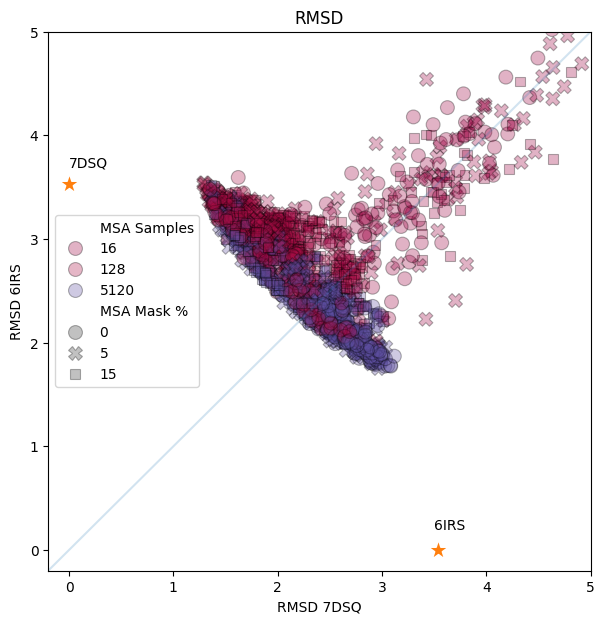

In [3]:
fig = plt.figure(figsize=(7,7))
plt.plot([-1,5], [-1,5], alpha=0.2)
sns.scatterplot(data=df, x="7DSQ_rmsd", y="6IRS_rmsd", hue="MSA Samples", style="MSA Mask %", edgecolors='black', palette=sns.color_palette("Spectral", as_cmap=True), alpha=0.3, s=100)
sns.scatterplot(x=[0, 3.534], y=[3.534, 0], marker="*", s=250)

plt.text(3.5, 0.2, '6IRS')
plt.text(0, 3.7, '7DSQ')
#tm_align(guide_coords[0], guide_coords[1], guide_seqs[1], guide_seqs[1])
plt.xlim((-0.2, 5))
plt.ylim((-0.2, 5))
plt.xlabel("RMSD 7DSQ")
plt.ylabel("RMSD 6IRS")
plt.title("RMSD")
#plt.savefig("subsampling-masking.svg")
plt.show(block=True)

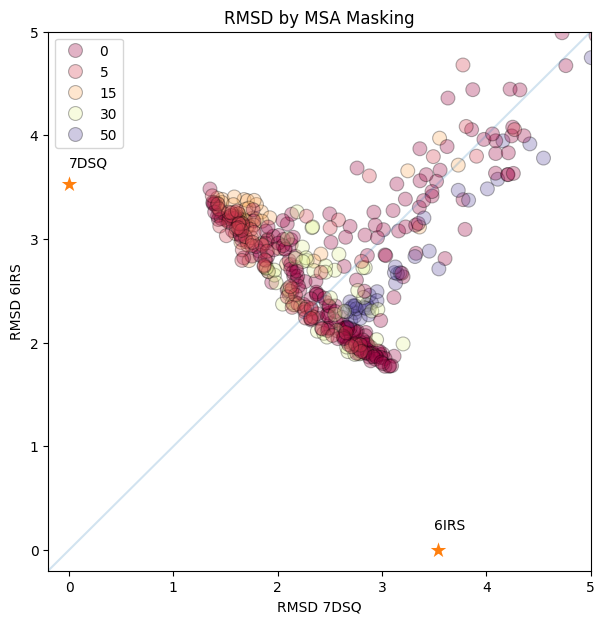

In [69]:
fig = plt.figure(figsize=(7,7))
plt.plot([-1,5], [-1,5], alpha=0.2)
sns.scatterplot(data=df_rmsd, x="7DSQ_rmsd", y="6IRS_rmsd", hue="MSA Mask %", edgecolors='black', palette=sns.color_palette("Spectral", as_cmap=True), alpha=0.3, s=100)
sns.scatterplot(x=[0, 3.534], y=[3.534, 0], marker="*", s=250)

plt.text(3.5, 0.2, '6IRS')
plt.text(0, 3.7, '7DSQ')
#tm_align(guide_coords[0], guide_coords[1], guide_seqs[1], guide_seqs[1])
plt.xlim((-0.2, 5))
plt.ylim((-0.2, 5))
plt.xlabel("RMSD 7DSQ")
plt.ylabel("RMSD 6IRS")
plt.title("RMSD by MSA Masking")
#plt.savefig("subsampling-masking.svg")
plt.show(block=True)

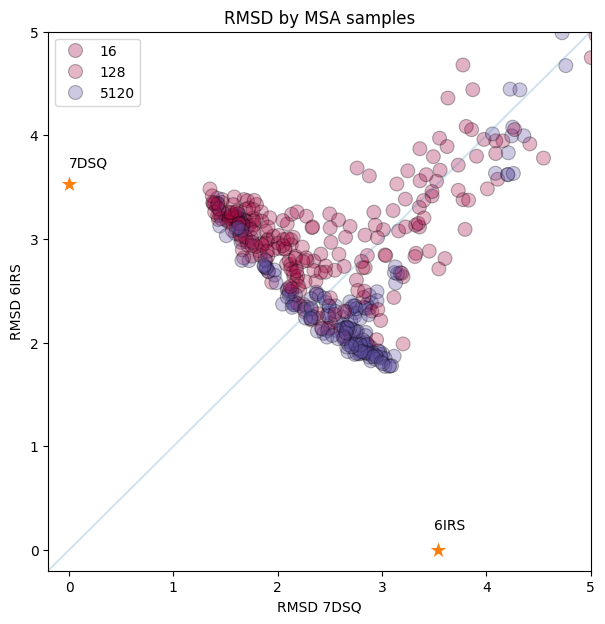

In [70]:
fig = plt.figure(figsize=(7,7))
plt.plot([-1,5], [-1,5], alpha=0.2)
sns.scatterplot(data=df_rmsd, x="7DSQ_rmsd", y="6IRS_rmsd", hue="MSA Samples", edgecolors='black', palette=sns.color_palette("Spectral", as_cmap=True), alpha=0.3, s=100)
sns.scatterplot(x=[0, 3.534], y=[3.534, 0], marker="*", s=250)

plt.text(3.5, 0.2, '6IRS')
plt.text(0, 3.7, '7DSQ')
#tm_align(guide_coords[0], guide_coords[1], guide_seqs[1], guide_seqs[1])
plt.xlim((-0.2, 5))
plt.ylim((-0.2, 5))
plt.xlabel("RMSD 7DSQ")
plt.ylabel("RMSD 6IRS")
plt.title("RMSD by MSA samples")
#plt.savefig("subsampling-masking.svg")
plt.show(block=True)

In [12]:
prt = {
 "7DSQ_tm": prots["points"][0], 
 "6IRS_tm": prots["points"][1],
 "msa_batch": prots["msa_batch"],
 "mean_plddt": prots["mean_plddt"],
 "MSA Samples": [int(x) for x in prots["subsample_sz"]],
 "MSA Mask %": prots["mask_fraction"]
}
df = pd.DataFrame(prt)

In [34]:
df["tm_score_agg"]  = (df["7DSQ_tm"] * 1/df["7DSQ_tm"].max())**.5 * (df["6IRS_tm"] * 1/df["6IRS_tm"].max())**.5

In [54]:
df["tm_score_agg"]  = ((df["7DSQ_tm"] * 1/df["7DSQ_tm"].max())**.5).rank()**2 + ((df["6IRS_tm"] * 1/df["6IRS_tm"].max())**.5).rank()**2

In [4]:
df

,7DSQ_rmsd,6IRS_rmsd,6IRS_tm,7DSQ_tm,rank,msa_batch,mean_plddt,MSA Samples,MSA Mask %,pdb_filename
0,1.710,3.370000,0.870046,0.955988,20,0,85.876509,128,15,runs/7DSQ_2/7DSQ_2_0_15_0/predictions/128/7DSQ...
1,1.577,3.336000,0.874595,0.962453,2,0,88.809741,128,15,runs/7DSQ_2/7DSQ_2_0_15_0/predictions/128/7DSQ...
2,1.608,3.182000,0.884940,0.960955,19,0,86.011078,128,15,runs/7DSQ_2/7DSQ_2_0_15_0/predictions/128/7DSQ...
3,1.727,3.294000,0.878242,0.955355,16,0,87.024159,128,15,runs/7DSQ_2/7DSQ_2_0_15_0/predictions/128/7DSQ...
4,1.841,2.957000,0.898005,0.950423,25,0,85.021530,128,15,runs/7DSQ_2/7DSQ_2_0_15_0/predictions/128/7DSQ...
...,...,...,...,...,...,...,...,...,...,...
1870,28.459,28.809999,0.123011,0.128312,12,0,43.477047,16,15,runs/7DSQ_2/7DSQ_2_5_15_2/predictions/16/7DSQ_...
1871,8.703,8.157000,0.666149,0.621685,9,0,48.934224,16,15,runs/7DSQ_2/7DSQ_2_5_15_2/predictions/16/7DSQ_...
1872,23.281,23.604000,0.266848,0.287486,11,0,44.819009,16,15,runs/7DSQ_2/7DSQ_2_5_15_2/predictions/16/7DSQ_...
1873,6.922,6.654000,0.785161,0.745911,7,0,52.294397,16,15,runs/7DSQ_2/7DSQ_2_5_15_2/predictions/16/7DSQ_...


In [63]:
df[df["tm_score_agg"] > 1345261.0]

,7DSQ_rmsd,6IRS_rmsd,6IRS_tm,7DSQ_tm,rank,msa_batch,mean_plddt,MSA Samples,MSA Mask %,tm_score_agg
0,1.469,3.382,0.869714,0.967363,11,0,87.665043,128,15,1356148.0
2,1.603,3.186,0.884619,0.961174,19,0,85.972500,128,15,1354952.0
23,1.465,3.353,0.872042,0.967648,6,0,88.151013,128,15,1370429.0
27,1.500,3.301,0.875659,0.966053,7,0,86.306746,512,15,1358381.0
35,1.493,3.229,0.881017,0.966275,24,0,84.064267,512,15,1400400.0
...,...,...,...,...,...,...,...,...,...,...
1095,1.508,3.032,0.893197,0.965930,6,0,85.640194,5120,5,1498465.0
1096,1.870,2.746,0.910207,0.948503,12,0,84.636789,5120,5,1347037.0
1097,2.343,2.247,0.935846,0.921268,25,0,82.279892,5120,5,1419170.0
1098,2.709,1.961,0.949318,0.899818,18,0,83.562198,5120,5,1494432.0


In [73]:
[get_pareto_front(df, '7DSQ_tm', '6IRS_tm').pdb_filename, get_pareto_front(df, '7DSQ_tm', '6IRS_tm')["6IRS_tm"]][0]

631     archive/25052026/7DSQ_2/7DSQ_2_0_0/predictions...
1020    archive/25052026/7DSQ_2/7DSQ_2_0_5/predictions...
630     archive/25052026/7DSQ_2/7DSQ_2_0_0/predictions...
628     archive/25052026/7DSQ_2/7DSQ_2_0_0/predictions...
627     archive/25052026/7DSQ_2/7DSQ_2_0_0/predictions...
649     archive/25052026/7DSQ_2/7DSQ_2_0_0/predictions...
641     archive/25052026/7DSQ_2/7DSQ_2_0_0/predictions...
640     archive/25052026/7DSQ_2/7DSQ_2_0_0/predictions...
1088    archive/25052026/7DSQ_2/7DSQ_2_0_5/predictions...
1057    archive/25052026/7DSQ_2/7DSQ_2_0_5/predictions...
1058    archive/25052026/7DSQ_2/7DSQ_2_0_5/predictions...
1095    archive/25052026/7DSQ_2/7DSQ_2_0_5/predictions...
1031    archive/25052026/7DSQ_2/7DSQ_2_0_5/predictions...
1034    archive/25052026/7DSQ_2/7DSQ_2_0_5/predictions...
1030    archive/25052026/7DSQ_2/7DSQ_2_0_5/predictions...
1083    archive/25052026/7DSQ_2/7DSQ_2_0_5/predictions...
1044    archive/25052026/7DSQ_2/7DSQ_2_0_5/predictions...
1092    archiv

In [33]:
get_pareto_front(df, '7DSQ_tm', '6IRS_tm')

,7DSQ_rmsd,6IRS_rmsd,6IRS_tm,7DSQ_tm,rank,msa_batch,mean_plddt,MSA Samples,MSA Mask %,pdb_filename
454,1.291,3.542,0.858891,0.975888,12,0,88.042953,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
471,1.292,3.523,0.861799,0.975587,19,0,86.850841,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
1203,1.325,3.433,0.865459,0.974618,6,0,88.838879,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...
450,1.339,3.437,0.867397,0.973398,2,0,89.719009,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
451,1.348,3.432,0.867457,0.973350,18,0,87.087931,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
1221,1.342,3.364,0.871806,0.973284,10,0,88.169720,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...
465,1.364,3.343,0.873280,0.972468,15,0,87.657522,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
470,1.369,3.320,0.875460,0.972194,23,0,85.430841,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
1839,1.385,3.237,0.879685,0.972169,5,0,80.844095,5120,15,localcolabfold/runs/7DSQ_2/7DSQ_2_5_15_2/predi...
1212,1.418,3.220,0.882100,0.970034,12,0,87.990797,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...


In [ ]:
get_pareto_front(relaxed_pareto2_df, '7DSQ_tm', '6IRS_tm')

,7DSQ_rmsd,6IRS_rmsd,6IRS_tm,7DSQ_tm,rank,msa_batch,mean_plddt,MSA Samples,MSA Mask %,pdb_filename
0,1.292,3.547,0.858786,0.975898,12,0,88.042953,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
1,1.290,3.526,0.861903,0.975718,19,0,86.850841,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
2,1.324,3.436,0.865513,0.974735,6,0,88.838879,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...
3,1.340,3.441,0.867568,0.973417,2,0,89.719009,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
5,1.344,3.367,0.871837,0.973248,10,0,88.169720,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...
63,1.366,3.360,0.872756,0.972505,16,0,87.575905,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
6,1.369,3.348,0.873323,0.972333,15,0,87.657522,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
8,1.386,3.243,0.879583,0.972209,5,0,80.844095,5120,15,localcolabfold/runs/7DSQ_2/7DSQ_2_5_15_2/predi...
9,1.417,3.222,0.882176,0.970097,12,0,87.990797,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...
10,1.426,3.199,0.882349,0.969742,11,0,88.139289,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...


In [34]:
import zipfile
from pathlib import Path


pareto = get_pareto_front(relaxed_pareto2_df, '7DSQ_tm', '6IRS_tm')
with zipfile.ZipFile('pareto_relaxed_pdbs.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file, I1, I2  in zip(pareto.pdb_filename, pareto["6IRS_tm"], pareto["7DSQ_tm"]):
        # Convert to Path object for easier manipulation
        path = Path(file.replace('unrelaxed', 'relaxed'))
        
        if path.exists():
            # arcname=path.name stores only the filename (e.g., 'data.csv')
            # instead of the full system path.
            zipf.write(path, arcname=str(I1)+"_"+str(I2)+".pdb")
            print(f"Added: {path.name}")
        else:
            print(f"Warning: File not found, skipping: {file}")

Added: 7DSQ_2_0_5_2_relaxed_rank_012_alphafold2_model_5_seed_001.pdb
Added: 7DSQ_2_0_5_2_relaxed_rank_019_alphafold2_model_4_seed_003.pdb
Added: 7DSQ_2_0_5_1_relaxed_rank_006_alphafold2_model_5_seed_000.pdb
Added: 7DSQ_2_0_5_2_relaxed_rank_002_alphafold2_model_3_seed_004.pdb
Added: 7DSQ_2_0_5_1_relaxed_rank_010_alphafold2_model_5_seed_002.pdb
Added: 7DSQ_2_0_5_2_relaxed_rank_016_alphafold2_model_4_seed_001.pdb
Added: 7DSQ_2_0_5_2_relaxed_rank_015_alphafold2_model_2_seed_001.pdb
Added: 7DSQ_2_5_15_2_relaxed_rank_005_alphafold2_model_5_seed_003.pdb
Added: 7DSQ_2_0_5_1_relaxed_rank_012_alphafold2_model_5_seed_003.pdb
Added: 7DSQ_2_0_5_1_relaxed_rank_011_alphafold2_model_2_seed_000.pdb
Added: 7DSQ_2_0_0_0_relaxed_rank_019_alphafold2_model_4_seed_003.pdb
Added: 7DSQ_2_0_5_0_relaxed_rank_001_alphafold2_model_5_seed_003.pdb
Added: 7DSQ_2_0_5_1_relaxed_rank_003_alphafold2_model_5_seed_003.pdb
Added: 7DSQ_2_0_15_2_relaxed_rank_016_alphafold2_model_5_seed_000.pdb
Added: 7DSQ_2_0_5_1_relaxed_rank

In [103]:
struct.to_sequence(mobile_struct)[0][0][16]

'V'

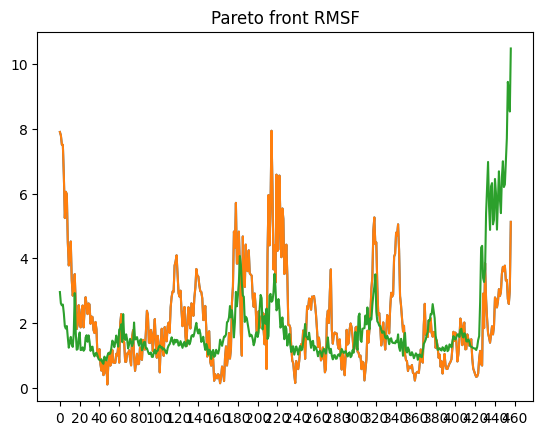

In [115]:
pareto_models = []
for i in pareto.pdb_filename:
    
#for i in glob.glob("boltz_7DSQ_*/*/predictions/*/*.pdb"):

    mobile_struct = biotite.structure.io.load_structure(i)
    if struct.to_sequence(mobile_struct)[0][0][16] != "V": continue
    mobile_struct = mobile_struct[mobile_struct.atom_name == "CA"][7:]
    mobile_struct, _ = struct.superimpose(guides[0], mobile_struct)
    #if i.split('predictions')[1].split("/")[1] + '_' + i.split("/")[-1].split("_")[3] not in all_models.keys():
    #    all_models[i.split('predictions')[1].split("/")[1] + '_' + i.split("/")[-1].split("_")[3]] = []
    #
    pareto_models.append(mobile_struct)
    
    

pareto_models = struct.stack(pareto_models)
avg = struct.average(pareto_models)
rm = []
for j in range(len(guides)):    
    #rmsf["rmsf"][j].append(np.sqrt(np.mean(np.square(struct.rmsf(guides[j], all_models[k])))))
    rm.append(struct.rmsf(guides[j], struct.stack(guides)))

rm.append(struct.rmsf(avg, all_models[k]))
    
#rmsfs[k] = np.mean(rm, axis=1)
#print(res.rmsd, res.tm_norm_chain1, res.tm_norm_chain2)
plt.xticks([x for x in range(0,464, 20)], [str(x) for x in range(0,464,20)])
for j in range(len(rm)):
    plt.plot(rm[j])
plt.title("Pareto front RMSF")
plt.show()


In [22]:
pareto_df =get_pareto_front(df, '7DSQ_tm', '6IRS_tm')

In [23]:
pareto_df

,7DSQ_rmsd,6IRS_rmsd,6IRS_tm,7DSQ_tm,rank,msa_batch,mean_plddt,MSA Samples,MSA Mask %,pdb_filename
454,1.291,3.542,0.858891,0.975888,12,0,88.042953,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
471,1.292,3.523,0.861799,0.975587,19,0,86.850841,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
1203,1.325,3.433,0.865459,0.974618,6,0,88.838879,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...
450,1.339,3.437,0.867397,0.973398,2,0,89.719009,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
451,1.348,3.432,0.867457,0.973350,18,0,87.087931,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
1221,1.342,3.364,0.871806,0.973284,10,0,88.169720,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...
465,1.364,3.343,0.873280,0.972468,15,0,87.657522,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
470,1.369,3.320,0.875460,0.972194,23,0,85.430841,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
1839,1.385,3.237,0.879685,0.972169,5,0,80.844095,5120,15,localcolabfold/runs/7DSQ_2/7DSQ_2_5_15_2/predi...
1212,1.418,3.220,0.882100,0.970034,12,0,87.990797,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...


In [ ]:
pd.concat([get_pareto_front(relaxed_pareto2_df, '7DSQ_tm', '6IRS_tm'),pareto_df]).drop_duplicates(keep=False)

,7DSQ_rmsd,6IRS_rmsd,6IRS_tm,7DSQ_tm,rank,msa_batch,mean_plddt,MSA Samples,MSA Mask %,pdb_filename
0,1.292,3.547,0.858786,0.975898,12,0,88.042953,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
1,1.290,3.526,0.861903,0.975718,19,0,86.850841,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
2,1.324,3.436,0.865513,0.974735,6,0,88.838879,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...
3,1.340,3.441,0.867568,0.973417,2,0,89.719009,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_2/predic...
5,1.344,3.367,0.871837,0.973248,10,0,88.169720,128,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...
...,...,...,...,...,...,...,...,...,...,...
715,2.784,1.849,0.953033,0.897973,19,0,84.156078,5120,0,localcolabfold/runs/7DSQ_2/7DSQ_2_5_0_1/predic...
719,2.899,1.803,0.955071,0.891800,16,0,84.288470,5120,0,localcolabfold/runs/7DSQ_2/7DSQ_2_5_0_1/predic...
707,2.887,1.814,0.955722,0.890540,2,0,85.661659,5120,0,localcolabfold/runs/7DSQ_2/7DSQ_2_5_0_1/predic...
1236,2.896,1.796,0.956407,0.889497,21,0,81.408944,5120,5,localcolabfold/runs/7DSQ_2/7DSQ_2_0_5_1/predic...


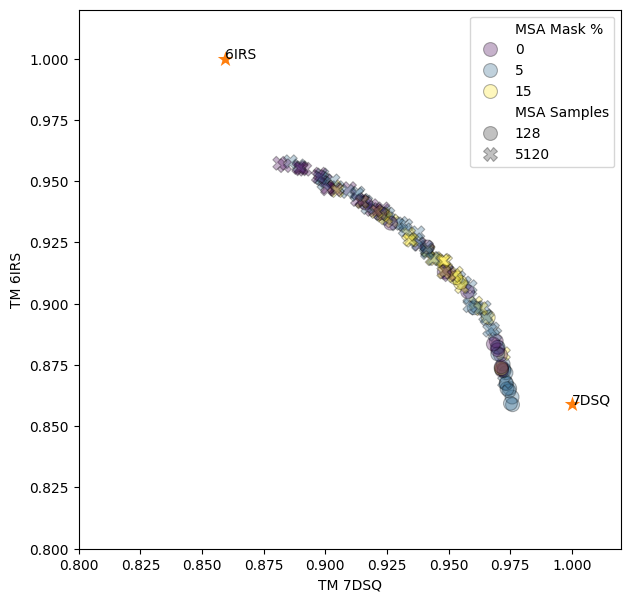

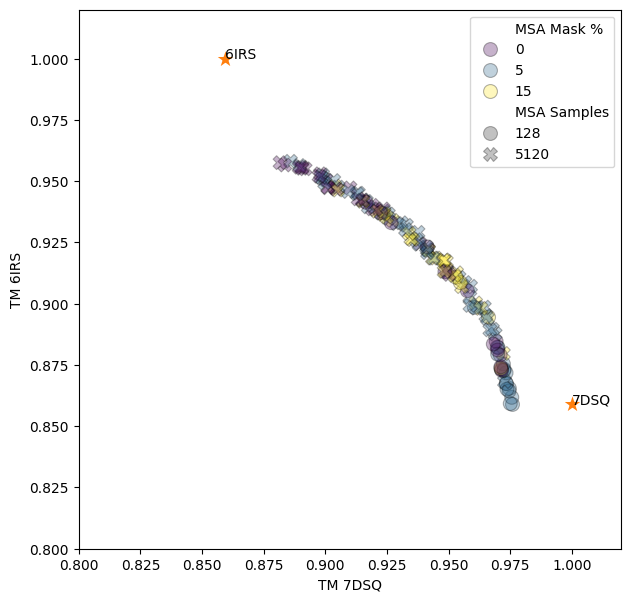

In [29]:
fig = plt.figure(figsize=(7,7))
#sns.scatterplot(data=get_pareto_front(df, '7DSQ_tm', '6IRS_tm'), x="7DSQ_tm", y="6IRS_tm", hue="MSA Mask %", style="MSA Samples", edgecolors='black', palette=sns.color_palette("viridis", as_cmap=True), alpha=0.3, s=100)
sns.scatterplot(data=relaxed_pareto2_df, x="7DSQ_tm", y="6IRS_tm", hue="MSA Mask %", style="MSA Samples", edgecolors='black', palette=sns.color_palette("viridis", as_cmap=True), alpha=0.3, s=100)
x_ref = [struct.tm_score(guides[0], guides[1], np.arange(len(guides[0])), np.arange(len(guides[0]))), struct.tm_score(guides[0], guides[0], np.arange(len(guides[0])), np.arange(len(guides[0])))]
y_ref = [struct.tm_score(guides[1], guides[1], np.arange(len(guides[0])), np.arange(len(guides[0]))), struct.tm_score(guides[1], guides[0], np.arange(len(guides[0])), np.arange(len(guides[0])))]
sns.scatterplot(x=x_ref, y=y_ref, marker="*", s=250)
plt.text(1, y_ref[1], '7DSQ')
plt.text(x_ref[0], 1, '6IRS')
#tm_align(guide_coords[0], guide_coords[1], guide_seqs[1], guide_seqs[1])
plt.xlim((0.8, 1.02))
plt.ylim((0.8, 1.02))
plt.xlabel("TM 7DSQ")
plt.ylabel("TM 6IRS")
#plt.title("Naive MSA Subsampling does not complement masking")
#plt.savefig("subsampling-masking.svg")
plt.show(block=True)

fig = plt.figure(figsize=(7,7))
#sns.scatterplot(data=get_pareto_front(df, '7DSQ_tm', '6IRS_tm'), x="7DSQ_tm", y="6IRS_tm", hue="MSA Mask %", style="MSA Samples", edgecolors='black', palette=sns.color_palette("viridis", as_cmap=True), alpha=0.3, s=100)
sns.scatterplot(data=pareto_2, x="7DSQ_tm", y="6IRS_tm", hue="MSA Mask %", style="MSA Samples", edgecolors='black', palette=sns.color_palette("viridis", as_cmap=True), alpha=0.3, s=100)
x_ref = [struct.tm_score(guides[0], guides[1], np.arange(len(guides[0])), np.arange(len(guides[0]))), struct.tm_score(guides[0], guides[0], np.arange(len(guides[0])), np.arange(len(guides[0])))]
y_ref = [struct.tm_score(guides[1], guides[1], np.arange(len(guides[0])), np.arange(len(guides[0]))), struct.tm_score(guides[1], guides[0], np.arange(len(guides[0])), np.arange(len(guides[0])))]
sns.scatterplot(x=x_ref, y=y_ref, marker="*", s=250)
plt.text(1, y_ref[1], '7DSQ')
plt.text(x_ref[0], 1, '6IRS')
#tm_align(guide_coords[0], guide_coords[1], guide_seqs[1], guide_seqs[1])
plt.xlim((0.8, 1.02))
plt.ylim((0.8, 1.02))
plt.xlabel("TM 7DSQ")
plt.ylabel("TM 6IRS")
#plt.title("Naive MSA Subsampling does not complement masking")
#plt.savefig("subsampling-masking.svg")
plt.show(block=True)

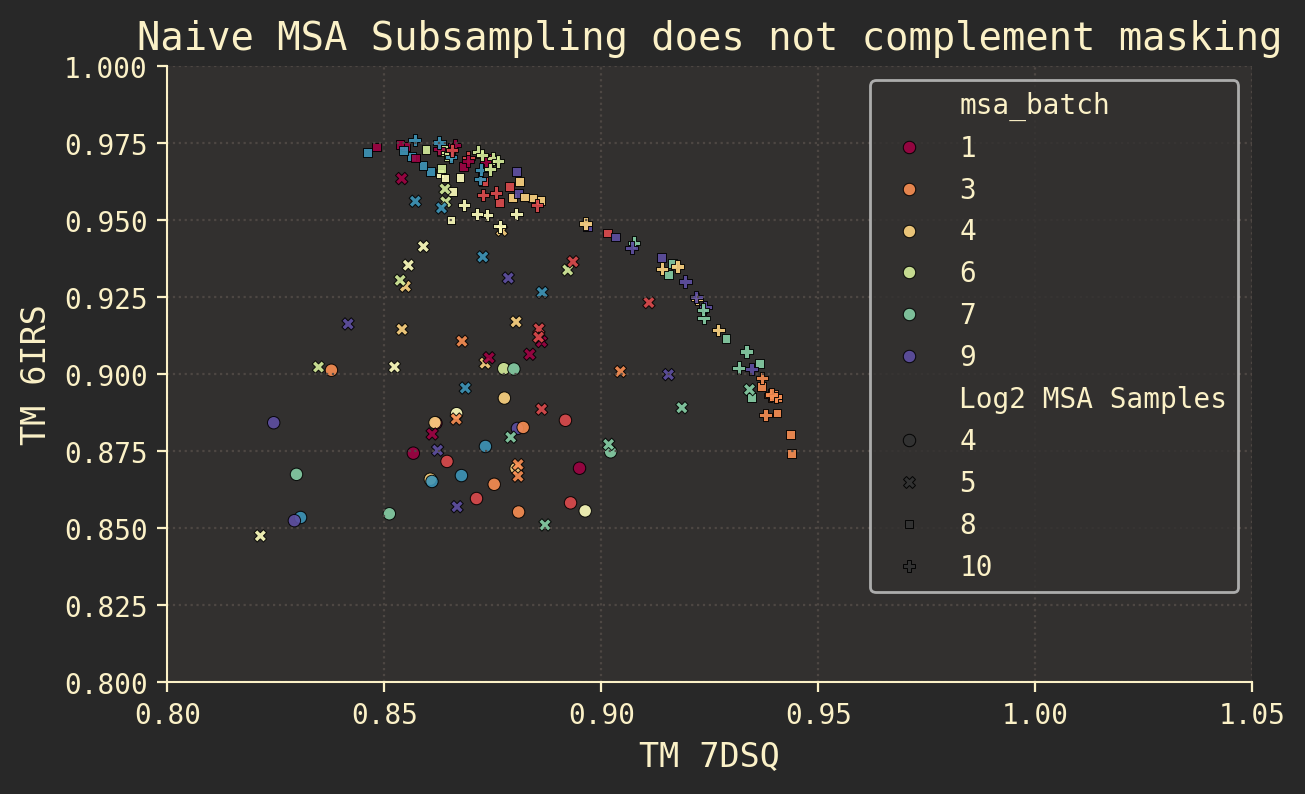

In [44]:
sns.scatterplot(data=df[df["mask_fraction"] == 15], x="7DSQ_tm", y="6IRS_tm", hue="msa_batch", style="Log2 MSA Samples", edgecolors='black', palette=sns.color_palette("Spectral", as_cmap=True), alpha=0.9, s=20)
plt.xlim((0.8, 1.05))
plt.ylim((0.8, 1))
plt.xlabel("TM 7DSQ")
plt.ylabel("TM 6IRS")
plt.title("Naive MSA Subsampling does not complement masking")
plt.savefig("subsampling-masking.svg")
plt.show(block=True)

In [27]:
 plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [45]:
from tmtools.io import get_residue_data, get_structure
from tmtools.helpers import transform_structure
from tmtools import tm_align
import glob
import matplotlib.pyplot as plt
# Load structures
from Bio.PDB import PDBParser
from Bio.PDB.PDBIO import PDBIO
import math
from tqdm import tqdm
import numpy as np
import json

plt.style.use('~/gruvbox.mplstyle')
parser = PDBParser()
io = PDBIO()

structures = [parser.get_structure("7DSQ", "localcolabfold/../7DSQ.pdb"), parser.get_structure("6IRS", "localcolabfold/../6IRS.pdb")]
for structure in structures:
    pdb_chains = structure.get_chains()
    for chain in pdb_chains:
        io.set_structure(chain)
        io.save(f"{structure.get_id()}_{chain.get_id()}.pdb")

guide_structs = [get_structure("localcolabfold/../6IRS_B.pdb"), get_structure("localcolabfold/../7DSQ_B.pdb")]

# Get relevant data from first chain
guide_coords, guide_seqs = [], []
for i in  [get_residue_data(next(guide_struct.get_chains())) for guide_struct in guide_structs]:
    guide_coords.append(i[0])
    guide_seqs.append(i[1])

prots = {
    "points": [[], []],
    "msa_batch": [],
    "mean_plddt": [],
    "subsample_sz": [],
    }

for i in tqdm(glob.glob("localcolabfold/7DSQ_2__*/*.pdb")):
    if("msa" in i): continue
#for i in glob.glob("boltz_7DSQ_*/*/predictions/*/*.pdb"):

    mobile_struct = get_structure(i)

    mobile_coords, mobile_seq = get_residue_data(next(mobile_struct.get_chains()))

    # Run TMalign
    #print(i + ":")
    prots["msa_batch"].append(int(i.split("/")[-1].split(".")[0].split("_")[1]))
    
    
    prots["subsample_sz"].append(math.log2(int(i.split("/")[-2].split("_")[-1])))
    
    prots["mean_plddt"].append(np.mean(json.load(open(i.replace("unrelaxed", "scores").replace(".pdb", ".json")))["plddt"]))
    
    for j in range(len(guide_structs)):
        res = tm_align(mobile_coords, guide_coords[j], mobile_seq, guide_seqs[j])
        aligned_mobile_struct = transform_structure(mobile_struct, res)
        prots["points"][j].append(res.tm_norm_chain1)
        #print(res.rmsd, res.tm_norm_chain1, res.tm_norm_chain2)

/home/friedrich/jupyterlab/.venv/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 8061.
  warnings.warn(
/home/friedrich/jupyterlab/.venv/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 7969.
  warnings.warn(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [00:57<00:00,  2.16it/s]


In [46]:
import pandas as pd
import seaborn as sns

In [47]:
nomasking = {
 "7DSQ_tm": prots["points"][0], 
 "6IRS_tm": prots["points"][1],
 "msa_batch": prots["msa_batch"],
 "mean_plddt": prots["mean_plddt"],
 "Log2 MSA Samples": [int(x) for x in prots["subsample_sz"]],
}

In [72]:
nomasking

{'7DSQ_tm': [0.9048145861137753,
  0.8979736867573255,
  0.9244171620032721,
  0.8829554836456014,
  0.9372940981240817,
  0.9393113060340167,
  0.9372754983317297,
  0.9001859460361362,
  0.9040569188593499,
  0.8904372070009274,
  0.9387284770521123,
  0.9306703634269813,
  0.9069949723138613,
  0.9228894983901109,
  0.9269997198885924,
  0.8624293268345266,
  0.8829616253424498,
  0.9287029699543015,
  0.9225792489163545,
  0.8900527456839847,
  0.8719786457850266,
  0.9373538283012193,
  0.9329386624548405,
  0.9330501422101364,
  0.9040136141654622,
  0.6969590453504899,
  0.3436050350617137,
  0.5717529782357651,
  0.8838943212488881,
  0.8893699791503681],
 '6IRS_tm': [0.9414310711465375,
  0.9493597900595605,
  0.9113464986800968,
  0.966713338018363,
  0.8935100221732436,
  0.8930493193157335,
  0.8897897937149636,
  0.9397508179018931,
  0.9247700780925738,
  0.947699991248534,
  0.886669776167624,
  0.900395802579097,
  0.9433128553764848,
  0.9262223171999897,
  0.907087771

In [13]:
df[df["subsample_sz"] == 10.0]

NameError: name 'df' is not defined

In [48]:
nomasking_df = pd.DataFrame(nomasking)

In [ ]:
sns.scatterplot(data=df[df["mask_fraction"] == 20][df[df["mask_fraction"] == 20]["subsample_sz"] == 10.0], x="7DSQ_tm", y="6IRS_tm", hue="mean_plddt", edgecolors='black', palette=sns.color_palette("Spectral", as_cmap=True), alpha=0.5, s=150, hue_norm=(80,95))
plt.xlim((0.8, 1))
plt.ylim((0.8, 1))
plt.xlabel("TM 7DSQ")
plt.ylabel("TM 6IRS")
plt.title("15% MSA masking induces fold diversity")
plt.show(block=True)

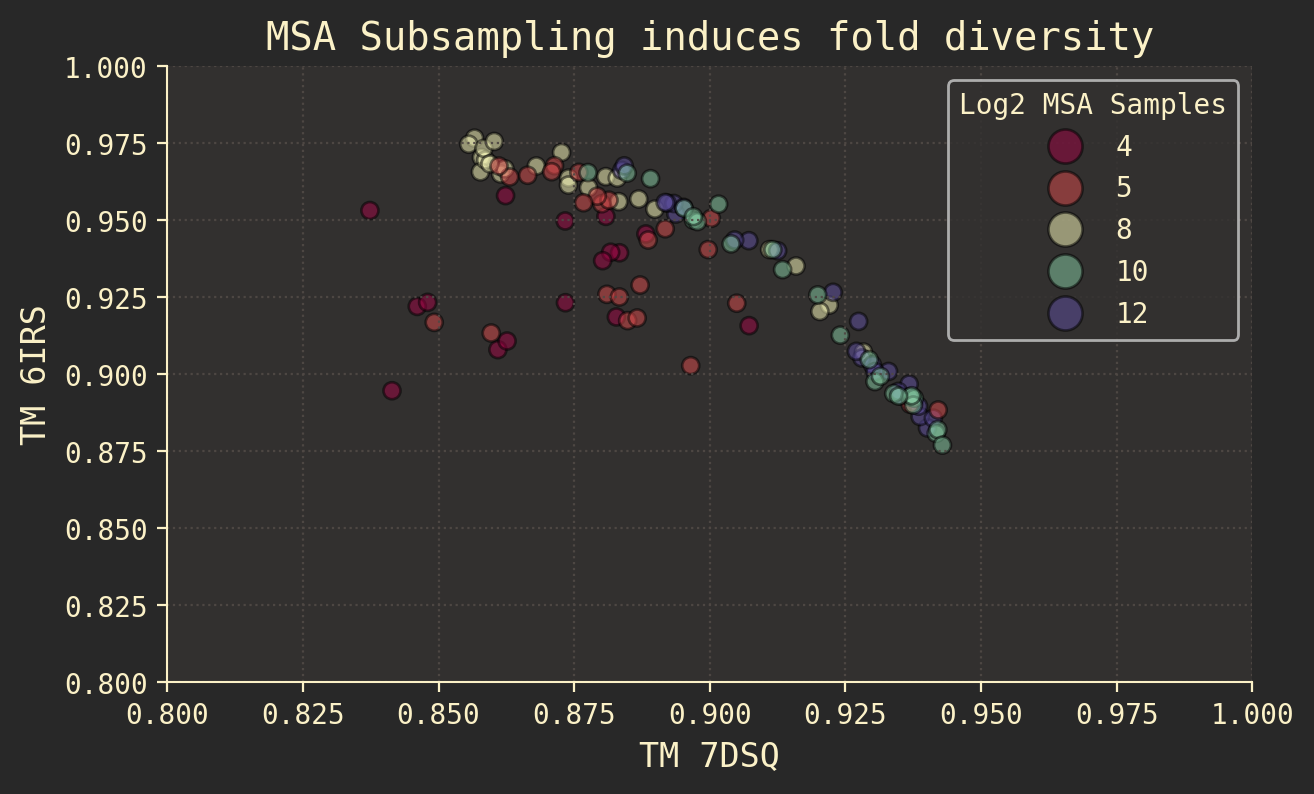

In [49]:
sns.scatterplot(data=nomasking_df, x="7DSQ_tm", y="6IRS_tm", hue="Log2 MSA Samples", edgecolors='black', palette=sns.color_palette("Spectral", as_cmap=True), alpha=0.5, s=150)
plt.xlim((0.8, 1))
plt.ylim((0.8, 1))
plt.xlabel("TM 7DSQ")
plt.ylabel("TM 6IRS")
plt.title("MSA Subsampling induces fold diversity")
plt.show(block=True)

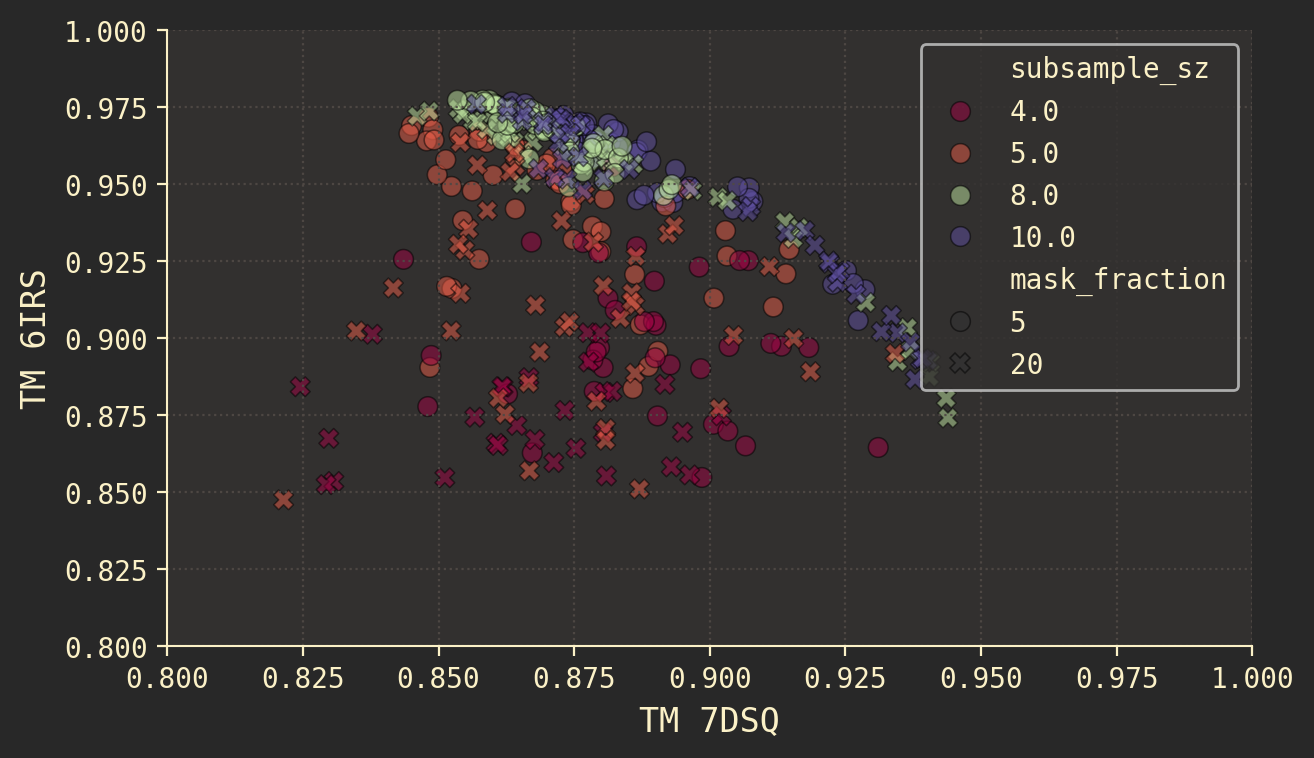

In [58]:
sns.scatterplot(data=df[df["mask_fraction"] < 21], x="7DSQ_tm", y="6IRS_tm", hue="subsample_sz", edgecolors='black', style="mask_fraction", palette=sns.color_palette("Spectral", as_cmap=True), alpha=0.5, s=50)
plt.xlim((0.8, 1))
plt.ylim((0.8, 1))
plt.xlabel("TM 7DSQ")
plt.ylabel("TM 6IRS")
plt.show(block=True)

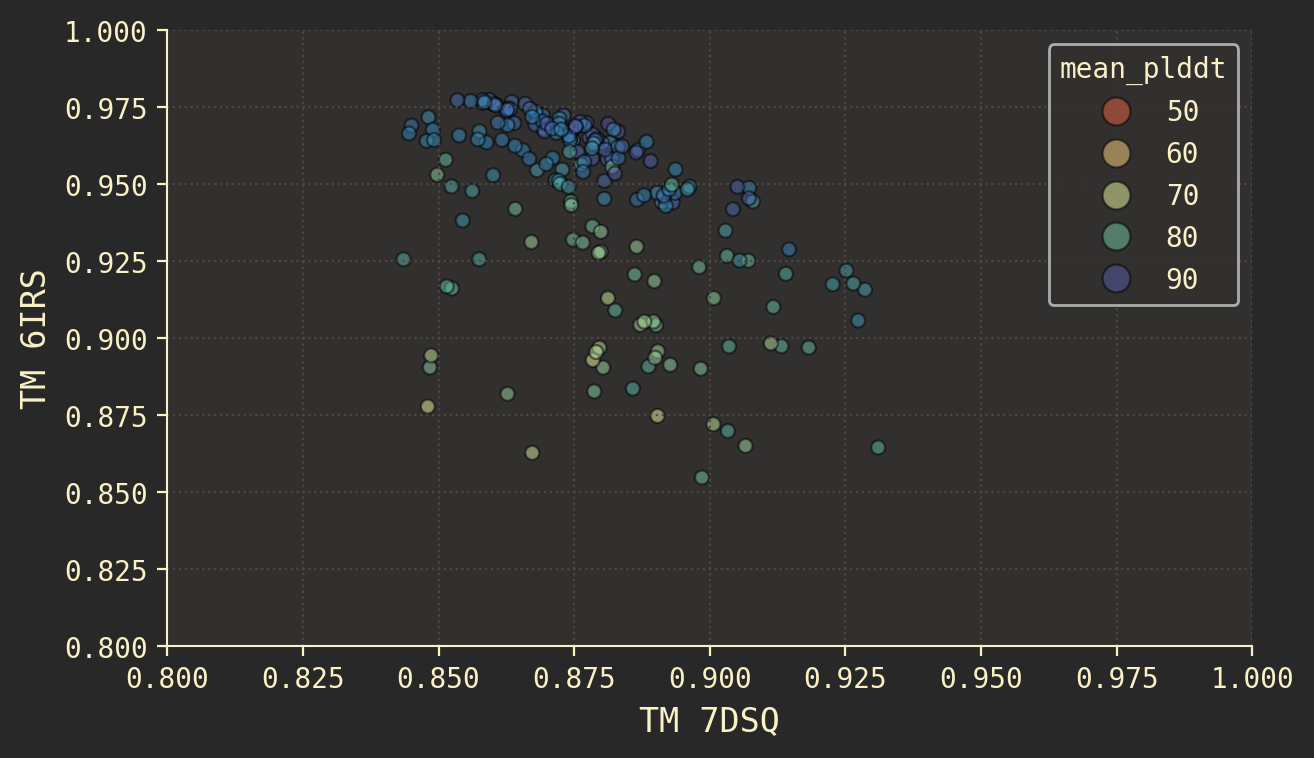

In [59]:
sns.scatterplot(data=df[df["mask_fraction"] == 5], x="7DSQ_tm", y="6IRS_tm", hue="mean_plddt", edgecolors='black', palette=sns.color_palette("Spectral", as_cmap=True), alpha=0.5, s=100)
plt.xlim((0.8, 1))
plt.ylim((0.8, 1))
plt.xlabel("TM 7DSQ")
plt.ylabel("TM 6IRS")
plt.show(block=True)

In [69]:
pts = [[], [], []]
for i in tqdm(glob.glob("localcolabfold/7DSQ_*/7DSQ_2_Chain_B_Large_neutral_amino_acids_transporter_small_subunit_1_Homo_sapiens__9606__unrelaxed_rank_*.pdb")):
#for i in glob.glob("../localcolabfold/boltz_7DSQ_*/*/predictions/*/*.pdb"):

    mobile_struct = get_structure(i)

    mobile_coords, mobile_seq = get_residue_data(next(mobile_struct.get_chains()))

    # Run TMalign
    print(i + ":")
    pts[2].append(math.log(int(i.split("/")[1].split("7DSQ_")[1].split("_")[1])))
    for j in range(len(guide_structs)):
        res = tm_align(mobile_coords, guide_coords[j], mobile_seq, guide_seqs[j])
        aligned_mobile_struct = transform_structure(mobile_struct, res)
        pts[j].append(res.tm_norm_chain1)
        print(res.rmsd, res.tm_norm_chain1, res.tm_norm_chain2)

localcolabfold/7DSQ_2_1024/7DSQ_2_Chain_B_Large_neutral_amino_acids_transporter_small_subunit_1_Homo_sapiens__9606__unrelaxed_rank_002_alphafold2_model_3_seed_000.pdb:
2.6120473193068463 0.9048145861137753 0.9178788487363531
2.0094961473296102 0.9414310711465375 0.9414310711465375
localcolabfold/7DSQ_2_1024/7DSQ_2_Chain_B_Large_neutral_amino_acids_transporter_small_subunit_1_Homo_sapiens__9606__unrelaxed_rank_003_alphafold2_model_1_seed_000.pdb:
2.7342119187981995 0.8979736867573255 0.9108667225865394
1.8600495865779059 0.9493597900595605 0.9493597900595605
localcolabfold/7DSQ_2_1024/7DSQ_2_Chain_B_Large_neutral_amino_acids_transporter_small_subunit_1_Homo_sapiens__9606__unrelaxed_rank_004_alphafold2_model_2_seed_000.pdb:
2.168960163320326 0.9244171620032721 0.9379336469572312
2.5386935384658855 0.9113464986800968 0.9113464986800968
localcolabfold/7DSQ_2_1024/7DSQ_2_Chain_B_Large_neutral_amino_acids_transporter_small_subunit_1_Homo_sapiens__9606__unrelaxed_rank_001_alphafold2_model_5_s

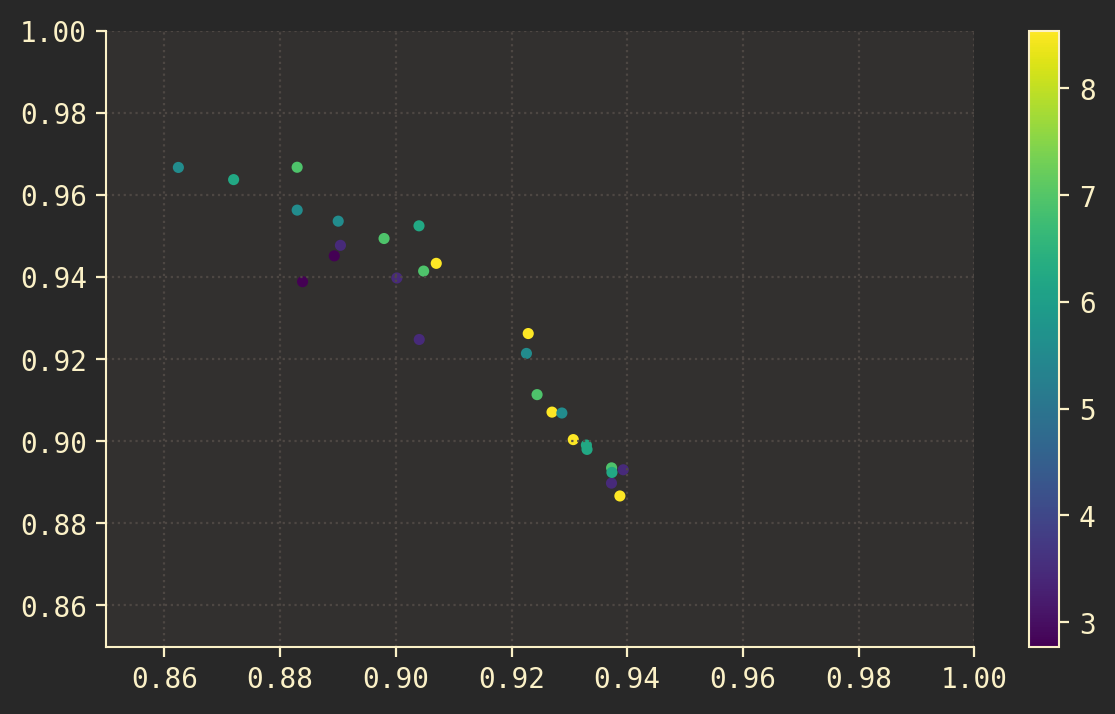

In [72]:

plt.scatter(pts[0], pts[1], c=pts[2])
plt.colorbar()
plt.xlim(0.85, 1)
plt.ylim(0.85, 1)
plt.show(block=True)